    # Practical 06 --- Remembering Every Experiment

    **Tracking runs, comparing them, and registering the winner with MLflow**

    SCSE3040 Machine Learning Operations &middot; Bennett University &middot; Session 2026-27

    | | |
    |---|---|
    | **Lectures this follows** | L11 |
    | **Course Outcome** | CO5 |
    | **Lab duration** | 120 minutes |
    | **Memory needed** | about 700 MB (fine on a 4 GB or 8 GB machine) |
    | **Extra software** | nothing beyond the course venv |
    | **Marks** | 10 |

    ---

    ## Aim

    1. Record the settings and the score of every training run automatically.
2. Search past runs and find the best one without opening a notebook.
3. Save a trained model as an artifact you can load again later.
4. Register that model so it has a name and a version number.

    ---

    ## What you need to know first


By P03 you had trained six models. Could you say, right now, which settings
produced the best score? Most people cannot. They tried things, kept the good
number in their head, and lost it.

That is the problem **experiment tracking** solves. Every time you train, a
tool records four things:

- **Parameters** --- the settings you chose. `max_depth=4`, `test_size=0.2`.
- **Metrics** --- the numbers that came out. `mae=2.03`.
- **Artifacts** --- files the run produced, above all the trained model itself.
- **Tags** --- your own labels, such as who ran it or why.

**MLflow** is the most widely used tool for this, and it is free and open
source. You add about three lines to your training code and everything is kept
for you, in a database you can query later.

Then there is the second half: the **model registry**. Tracking answers "what
did I try?". The registry answers "which model is the one we actually use?" It
gives a model a name and a **version number**, so the team can say *delivery-time
model, version 3* and everybody means the same file.

One warning before you start, and it will save you an hour. Almost every
tutorial and textbook older than 2025 tells you MLflow stores runs in a folder
called `./mlruns`. **MLflow 3 put that folder store into maintenance mode.** If
you follow those instructions you will get confusing errors. The current
approach, and the one we use today, is a small database file. It is one line
different, and it works.

    ---

    ## Before you start

    - Practicals P02-P04 are finished. You can train a model and score it.
- You know what a dictionary is, and what a CSV file is.

    ### How to run a cell

    Click on a grey code cell, then press **Shift + Enter**. The cell runs and
    the cursor moves to the next one. A number appears in the `[ ]` on the left
    when the cell has finished.

    **Run the cells in order, from the top.** A later cell almost always uses
    something an earlier cell created. If you jump ahead you will see a
    `NameError`, which just means "you have not made that thing yet".

    If everything goes wrong, use the menu: **Kernel -> Restart Kernel and Clear
    All Outputs**, then start again from the first cell. Nothing is damaged by
    doing this.

In [1]:
# Step 0 --- check the workbench before we start.
# This cell only looks; it changes nothing. Run it and read the last line.

import sys
from pathlib import Path

print("Python  :", sys.version.split()[0])
print("Folder  :", Path.cwd().name)

_missing = []
for _name in ['numpy', 'pandas', 'sklearn', 'mlflow', 'matplotlib']:
    try:
        __import__(_name)
    except ImportError:
        _missing.append(_name)

for _name in ['numpy', 'pandas', 'sklearn', 'mlflow', 'matplotlib']:
    _mark = "missing" if _name in _missing else "ok"
    print(f"  {_name:<14} {_mark}")

if _missing:
    print()
    print("STOP. Some libraries are missing:", ", ".join(_missing))
    print("Ask your instructor to run the setup in labs/SETUP.md.")
else:
    print()
    print("All good. You can carry on to Step 1.")

Python  : 3.12.5
Folder  : P06-mlflow
  numpy          ok
  pandas         ok
  sklearn        ok
  mlflow         ok
  matplotlib     ok

All good. You can carry on to Step 1.


---

## Step 0b --- the dataset

Every practical in this course uses the same 600 food deliveries.
The next cell makes sure the file is there.

In [2]:
# The delivery-time dataset every practical in this course uses.
# If the file is missing we build it again from the same seed, so every
# student in the room gets byte-for-byte the same 600 rows.

import csv
from pathlib import Path

import numpy as np

SEED = 42
N_ROWS = 600
DATA = Path("..") / "data" / "delivery_times.csv"


def make_delivery_csv(path=DATA):
    """Write the 600-row delivery dataset. Same formula as the lectures."""
    rng = np.random.default_rng(SEED)
    distance_km = np.round(rng.uniform(0.5, 12.0, N_ROWS), 2)
    prep_time_min = np.round(rng.uniform(5, 30, N_ROWS), 0)
    traffic_level = rng.integers(1, 4, N_ROWS)
    rain = rng.binomial(1, 0.25, N_ROWS)
    delivery_min = np.round(
        6.0
        + 3.1 * distance_km
        + 0.65 * prep_time_min
        + 4.2 * traffic_level
        + 5.5 * rain
        + rng.normal(0, 2.5, N_ROWS),
        1,
    )
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(["distance_km", "prep_time_min", "traffic_level",
                    "rain", "delivery_min"])
        for i in range(N_ROWS):
            w.writerow([distance_km[i], int(prep_time_min[i]),
                        int(traffic_level[i]), int(rain[i]), delivery_min[i]])
    return path


if not DATA.exists():
    make_delivery_csv()
    print("dataset rebuilt ->", DATA)
else:
    print("dataset found   ->", DATA)

dataset found   -> ..\data\delivery_times.csv


---

# Walkthrough

Read each step, then run its cell.

### Step 1 --- The problem, in one cell

Train three models with different settings, the way you did in P03.
Read the output, then close your eyes and try to recall the second
model's settings.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

WORK = Path("work")
WORK.mkdir(exist_ok=True)

orders = pd.read_csv(DATA)
FEATURES = ["distance_km", "prep_time_min", "traffic_level", "rain"]
X_train, X_test, y_train, y_test = train_test_split(
    orders[FEATURES], orders["delivery_min"],
    test_size=0.2, random_state=42,
)

for n_trees, depth in [(50, 4), (150, 8), (300, 12)]:
    m = RandomForestRegressor(n_estimators=n_trees, max_depth=depth,
                              random_state=42).fit(X_train, y_train)
    mae = mean_absolute_error(y_test, m.predict(X_test))
    print(f"n_estimators={n_trees:3d} max_depth={depth:2d} -> "
          f"MAE {mae:.3f}")

n_estimators= 50 max_depth= 4 -> MAE 3.529
n_estimators=150 max_depth= 8 -> MAE 2.427
n_estimators=300 max_depth=12 -> MAE 2.379


Those numbers exist only on your screen. Close the notebook and they
are gone. Now let us keep them.

### Step 2 --- Point MLflow at a database

MLflow needs somewhere to write. We give it a **SQLite** database ---
a whole database that is just one file, needing no server.

This is the line every old tutorial gets wrong. Do not use
`./mlruns`; use a database, like this.

In [4]:
import shutil

import mlflow
import mlflow.sklearn

# Teaching notebooks should start from a known state, so that your
# numbers match your instructor's. This clears any previous run of
# THIS notebook. You would never do this on a real project -- the
# whole value of the database is that it remembers.
db_path = (WORK / "mlflow.db").resolve()
db_path.unlink(missing_ok=True)
shutil.rmtree("mlartifacts", ignore_errors=True)

TRACKING_URI = f"sqlite:///{db_path.as_posix()}"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("delivery-time")

print("tracking store:", TRACKING_URI)

2026/09/24 15:59:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/24 15:59:30 INFO mlflow.store.db.utils: Updating database tables
2026/09/24 15:59:33 INFO mlflow.tracking.fluent: Experiment with name 'delivery-time' does not exist. Creating a new experiment.


tracking store: sqlite:///C:/Users/Mitaksh Jhanwar/MLOps/P06-mlflow/work/mlflow.db


MLflow prints a few `INFO` lines about creating database tables.
That is normal.

An **experiment** is just a folder for related runs. Ours is called
`delivery-time`.

**If you re-run this cell later, it wipes the database and starts
again.** That is a choice we made for teaching. Skip this cell if
you want to keep yesterday's runs.

### Step 3 --- Your first tracked run

`with mlflow.start_run():` opens a run. Everything logged inside is
attached to it. When the block ends, the run is closed and saved.

Three kinds of thing go in: parameters, metrics, tags.

In [5]:
with mlflow.start_run(run_name="first-try") as run:
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 50)
    mlflow.log_param("max_depth", 4)

    model = RandomForestRegressor(
        n_estimators=50, max_depth=4, random_state=42
    ).fit(X_train, y_train)

    mae = mean_absolute_error(y_test, model.predict(X_test))
    mlflow.log_metric("mae_minutes", mae)
    mlflow.set_tag("run_by", "student")

    first_run_id = run.info.run_id

print("run id :", first_run_id)
print("MAE    :", round(mae, 3))

run id : 378ed6eb6f424faaafd3a812985dc4c0
MAE    : 3.529


That run is now in the database permanently. Delete this notebook
and the record survives.

### Step 4 --- Read it back

`mlflow.search_runs` hands you every run as a table. Parameters
appear as `params.<name>` columns and metrics as `metrics.<name>`.

In [6]:
runs = mlflow.search_runs(experiment_names=["delivery-time"])

print("runs recorded:", len(runs))
print()
print(runs[["run_id", "params.n_estimators", "params.max_depth",
            "metrics.mae_minutes"]].to_string(index=False))

runs recorded: 1

                          run_id params.n_estimators params.max_depth  metrics.mae_minutes
378ed6eb6f424faaafd3a812985dc4c0                  50                4             3.528755


You did not save that table anywhere. MLflow did.

### Step 5 --- Log a whole sweep of settings

Now the real benefit. Wrap the loop from Step 1 in tracking, and
every combination is recorded as you go.

Note what is *not* here: no spreadsheet, no notes file, no
remembering.

In [7]:
SETTINGS = [(50, 4), (150, 8), (300, 12), (100, 6), (200, None)]

for n_trees, depth in SETTINGS:
    with mlflow.start_run(run_name=f"rf-n{n_trees}-d{depth}"):
        mlflow.log_param("model_type", "RandomForestRegressor")
        mlflow.log_param("n_estimators", n_trees)
        mlflow.log_param("max_depth", depth)

        m = RandomForestRegressor(
            n_estimators=n_trees, max_depth=depth, random_state=42
        ).fit(X_train, y_train)

        preds = m.predict(X_test)
        mlflow.log_metric("mae_minutes",
                          mean_absolute_error(y_test, preds))
        mlflow.log_metric(
            "rmse_minutes",
            float(np.sqrt(((y_test - preds) ** 2).mean())),
        )
        print(f"  logged rf-n{n_trees}-d{depth}")

print("done")

  logged rf-n50-d4
  logged rf-n150-d8
  logged rf-n300-d12
  logged rf-n100-d6
  logged rf-n200-dNone
done


### Step 6 --- Find the winner without looking at a notebook

Ask the database directly: sort by error, smallest first, and take
the top row. This is the query a colleague would run months from
now.

In [8]:
best_runs = mlflow.search_runs(
    experiment_names=["delivery-time"],
    order_by=["metrics.mae_minutes ASC"],
)

columns = ["tags.mlflow.runName", "params.n_estimators",
           "params.max_depth", "metrics.mae_minutes"]
print(best_runs[columns].head(6).to_string(index=False))

winner = best_runs.iloc[0]
print()
print("WINNER:", winner["tags.mlflow.runName"],
      "with MAE", round(winner["metrics.mae_minutes"], 3))

tags.mlflow.runName params.n_estimators params.max_depth  metrics.mae_minutes
        rf-n300-d12                 300               12             2.379120
      rf-n200-dNone                 200             None             2.411408
         rf-n150-d8                 150                8             2.427124
         rf-n100-d6                 100                6             2.613706
          rf-n50-d4                  50                4             3.528755
          first-try                  50                4             3.528755

WINNER: rf-n300-d12 with MAE 2.379


Look at how close the top three are: about 2.38, 2.41 and 2.43
minutes. Tripling the number of trees bought you a twentieth of a
minute.

MLflow did not teach you that. It just made sure you could still
check it a month from now, when somebody asks whether the extra
trees were worth the training time.

### Step 7 --- Draw the sweep from the database

The MLflow web page (Step 11) draws charts like this one. You can
draw the same chart yourself, straight from `search_runs`, and
that is how a team's own dashboard is built: not from memory, not
from a spreadsheet, from the database.

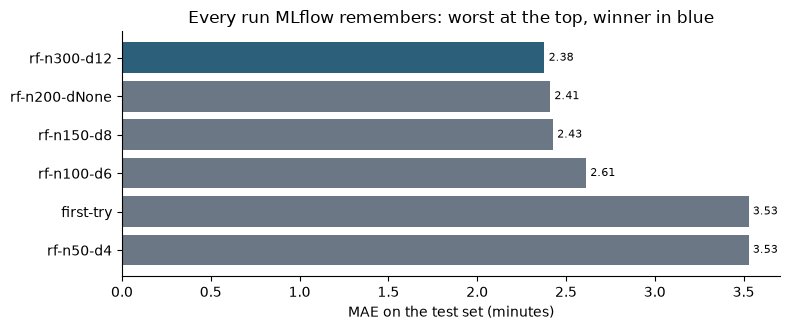

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

table = (best_runs[["tags.mlflow.runName", "metrics.mae_minutes"]]
         .sort_values("metrics.mae_minutes", ascending=False))
winner_name = winner["tags.mlflow.runName"]
colours = ["#2C5F79" if name == winner_name else "#6B7785"
           for name in table["tags.mlflow.runName"]]

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.barh(table["tags.mlflow.runName"],
               table["metrics.mae_minutes"], color=colours)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.set_xlabel("MAE on the test set (minutes)")
ax.set_title("Every run MLflow remembers: worst at the top, winner in blue")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Six bars, one per run, read from the database. The bottom three
are nearly the same length --- that is the "tripling the trees
bought a twentieth of a minute" point, made visible. The MLflow
page you open in Step 11 shows exactly this, with less code.

### Step 8 --- Save the winning model itself

Parameters and metrics describe a model. They are not the model. To
use it later you must store the trained object too, as an
**artifact**.

This cell takes longer than the others --- MLflow also records the
library versions needed to load the model again. Give it half a
minute.

In [10]:
best_trees = int(winner["params.n_estimators"])
best_depth = winner["params.max_depth"]
best_depth = None if best_depth in ("None", None) else int(best_depth)

with mlflow.start_run(run_name="champion") as champion:
    mlflow.log_param("n_estimators", best_trees)
    mlflow.log_param("max_depth", best_depth)

    champion_model = RandomForestRegressor(
        n_estimators=best_trees, max_depth=best_depth,
        random_state=42,
    ).fit(X_train, y_train)

    mlflow.log_metric(
        "mae_minutes",
        mean_absolute_error(y_test, champion_model.predict(X_test)),
    )

    mlflow.sklearn.log_model(
        champion_model,
        name="model",
        input_example=X_train.head(3),
        registered_model_name="delivery-time-model",
        skops_trusted_types=["sklearn.tree._tree.Tree"]
    )
    champion_id = champion.info.run_id

print("champion run:", champion_id)

c:\Users\Mitaksh Jhanwar\MLOps\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


champion run: afa7f7d5d6014f2ebc967ffea3e46016


Successfully registered model 'delivery-time-model'.
Created version '1' of model 'delivery-time-model'.


`registered_model_name` did two jobs at once: it stored the model
file, and it entered that file into the **registry** under a name.

### Step 9 --- Look at the registry

The registry is a separate list: named models, each with numbered
versions. Run this cell twice and you will see version 2 appear ---
that is the point of it.

In [11]:
from mlflow import MlflowClient

client = MlflowClient()

for mv in client.search_model_versions(
    "name='delivery-time-model'"
):
    print(f"name={mv.name}  version={mv.version}  "
          f"run_id={mv.run_id[:8]}...")

name=delivery-time-model  version=1  run_id=afa7f7d5...


### Step 10 --- Load a model back, by name and version

This is the payoff. You do not need the notebook that trained it,
the variable it was in, or the person who ran it. You need its name
and version.

In P07 this exact idea puts a model behind a web address.

In [12]:
loaded = mlflow.sklearn.load_model("models:/delivery-time-model/1")

one_order = pd.DataFrame([{
    "distance_km": 5.0,
    "prep_time_min": 20,
    "traffic_level": 2,
    "rain": 0,
}])

print("loaded model type:", type(loaded).__name__)
print("prediction:", round(float(loaded.predict(one_order)[0]), 1),
      "minutes")

loaded model type: RandomForestRegressor
prediction: 42.9 minutes


### Step 11 --- See it in the web interface

Everything you logged has a web page. We are not going to run it
inside the notebook --- a web server would block this cell forever.

Open a **terminal** (Anaconda Prompt or PowerShell), go to this
practical's folder, and run the command printed below. Then visit
<http://127.0.0.1:5000> in your browser.

Press `Ctrl + C` in the terminal to stop it when you are done.

In [13]:
print("Run this in a terminal, from the folder containing work/ :")
print()
print(f"  cd {Path.cwd()}")
print("  python -m mlflow ui --backend-store-uri "
      f"{TRACKING_URI} --port 5000")
print()
print("Then open http://127.0.0.1:5000")
print()
print("What you will see first: an empty 'Experiments' page.")
print("Click 'delivery-time' in the left sidebar to get the run")
print("table. Tick two runs and press Compare to see them side")
print("by side. The Models tab at the top shows the registry.")

Run this in a terminal, from the folder containing work/ :

  cd c:\Users\Mitaksh Jhanwar\MLOps\P06-mlflow
  python -m mlflow ui --backend-store-uri sqlite:///C:/Users/Mitaksh Jhanwar/MLOps/P06-mlflow/work/mlflow.db --port 5000

Then open http://127.0.0.1:5000

What you will see first: an empty 'Experiments' page.
Click 'delivery-time' in the left sidebar to get the run
table. Tick two runs and press Compare to see them side
by side. The Models tab at the top shows the registry.


Take a screenshot of the run table with the `mae_minutes` column
visible --- you need it for your submission.

---

# Your turn

The walkthrough above is finished. Now you write some code.

There are **3 tasks**. Each one is small. Each one has a hint.
Do them in order.

Where you see `# TODO`, replace that line with your own code. Do not delete
the variable name on the left of the `=` sign --- the self-check at the
bottom looks for exactly that name.

When you have tried all three, run the **self-check** cell at the end. It
prints a table telling you which tasks are correct. You can run it as many
times as you like.

### Task T1 --- Track a different kind of model


    Log one new run, named exactly `linear-baseline`, that:

    - trains a `LinearRegression` on `X_train` / `y_train`
    - logs a parameter `model_type` with the value `LinearRegression`
    - logs a metric `mae_minutes` with its error on the test set

    Store the run's id in `T1_run_id`.


> **Hint.** Copy Step 3 and change three things: the run name, the model, and the value of `model_type`. `LinearRegression` needs importing from `sklearn.linear_model`. Get the id with `run.info.run_id` inside the `with` block.

In [14]:
from sklearn.linear_model import LinearRegression

with mlflow.start_run(run_name="linear-baseline") as run:
    mlflow.log_param("model_type", "LinearRegression")
    
    model = LinearRegression().fit(X_train, y_train)
    mae = mean_absolute_error(y_test, model.predict(X_test))
    
    mlflow.log_metric("mae_minutes", mae)
    
    T1_run_id = run.info.run_id

print("T1_run_id =", T1_run_id)

T1_run_id = 125ab7a6b8d34c25a2e1fbbdf0ed1943


### Task T2 --- Ask the database, not your memory


    Without reading any earlier output, use `mlflow.search_runs` to find the
    run with the **lowest** `mae_minutes` across the whole `delivery-time`
    experiment.

    Put its run name in `T2_best_name` and its error in `T2_best_mae`.


> **Hint.** Step 6 shows the pattern: pass `order_by=["metrics.mae_minutes ASC"]`, then take `.iloc[0]`. The run name lives in the column `tags.mlflow.runName`.

In [15]:
T2_runs = mlflow.search_runs(
    experiment_names=["delivery-time"],
    order_by=["metrics.mae_minutes ASC"]
)

best_run = T2_runs.iloc[0]
T2_best_name = best_run["tags.mlflow.runName"]
T2_best_mae = best_run["metrics.mae_minutes"]

print(T2_best_name, T2_best_mae)

linear-baseline 1.924653079833835


### Task T3 --- A sweep you can filter later


    Run a small sweep of `DecisionTreeRegressor` at depths `[2, 4, 6]`.
    For each depth, log one run that:

    - is tagged `family` = `tree`
    - logs the parameter `max_depth`
    - logs the metric `mae_minutes`

    Then query MLflow for runs with that tag and put the count in
    `T3_tree_runs`.


> **Hint.** `mlflow.set_tag("family", "tree")` goes inside the `with` block. To find them again, use `filter_string="tags.family = 'tree'"` in `search_runs`. The count is just `len(...)` of the result.

In [16]:
from sklearn.tree import DecisionTreeRegressor

for depth in [2, 4, 6]:
    with mlflow.start_run(run_name=f"tree-d{depth}"):
        mlflow.set_tag("family", "tree")
        mlflow.log_param("max_depth", depth)
        
        m = DecisionTreeRegressor(max_depth=depth, random_state=42).fit(X_train, y_train)
        mae = mean_absolute_error(y_test, m.predict(X_test))
        
        mlflow.log_metric("mae_minutes", mae)

tree_runs_df = mlflow.search_runs(
    experiment_names=["delivery-time"],
    filter_string="tags.family = 'tree'"
)
T3_tree_runs = len(tree_runs_df)

print("runs tagged family=tree:", T3_tree_runs)

runs tagged family=tree: 3


---

## Self-check

Run the cell below to mark your work.

In [17]:
# ------------------------------------------------------------------
# SELF-CHECK --- run this when you have attempted the tasks above.
# It never breaks your notebook. A task you have not done yet simply
# shows FAIL.
# ------------------------------------------------------------------

_results = []


def _check(label, fn):
    """Evaluate one graded condition without ever raising."""
    try:
        ok = bool(fn())
    except Exception:
        ok = False
    _results.append((label, ok))


_check('T1 | a run named linear-baseline exists in MLflow', lambda: len(mlflow.search_runs(experiment_names=['delivery-time'], filter_string="tags.mlflow.runName = 'linear-baseline'")) >= 1)
_check("T1 | T1_run_id is that run's id", lambda: T1_run_id in set(mlflow.search_runs(experiment_names=['delivery-time'], filter_string="tags.mlflow.runName = 'linear-baseline'")['run_id']))
_check('T1 | it logged model_type and a sensible mae_minutes', lambda: (lambda r: r['params.model_type'].iloc[0] == 'LinearRegression' and 0 < float(r['metrics.mae_minutes'].iloc[0]) < 15)(mlflow.search_runs(experiment_names=['delivery-time'], filter_string="tags.mlflow.runName = 'linear-baseline'")))
_check('T2 | T2_best_mae really is the smallest error recorded', lambda: abs(float(T2_best_mae) - float(mlflow.search_runs(experiment_names=['delivery-time'])['metrics.mae_minutes'].min())) < 1e-6)
_check('T2 | T2_best_name is the run that holds it', lambda: T2_best_name == mlflow.search_runs(experiment_names=['delivery-time'], order_by=['metrics.mae_minutes ASC']).iloc[0]['tags.mlflow.runName'])
_check('T3 | three runs are tagged family=tree', lambda: len(mlflow.search_runs(experiment_names=['delivery-time'], filter_string="tags.family = 'tree'")) == 3)
_check('T3 | T3_tree_runs reports that count', lambda: int(T3_tree_runs) == 3)
_check('T3 | each tagged run logged a max_depth of 2, 4 or 6', lambda: set(mlflow.search_runs(experiment_names=['delivery-time'], filter_string="tags.family = 'tree'")['params.max_depth']) == {'2', '4', '6'})

print("==================================================================")
print("SELF-CHECK   Practical 06 --- Remembering Every Experiment")
print("==================================================================")
for _label, _ok in _results:
    print(f"  [{'PASS' if _ok else 'FAIL'}]  {_label}")
print("------------------------------------------------------------------")
_passed = sum(1 for _, _ok in _results if _ok)
print(f"  {_passed} of {len(_results)} checks passed")
print("==================================================================")
if _passed == len(_results):
    print("Well done. Save the notebook and submit it.")
else:
    print("Read the FAIL lines above, fix those tasks, run this cell again.")

SELF-CHECK   Practical 06 --- Remembering Every Experiment
  [PASS]  T1 | a run named linear-baseline exists in MLflow
  [PASS]  T1 | T1_run_id is that run's id
  [PASS]  T1 | it logged model_type and a sensible mae_minutes
  [PASS]  T2 | T2_best_mae really is the smallest error recorded
  [PASS]  T2 | T2_best_name is the run that holds it
  [PASS]  T3 | three runs are tagged family=tree
  [PASS]  T3 | T3_tree_runs reports that count
  [PASS]  T3 | each tagged run logged a max_depth of 2, 4 or 6
------------------------------------------------------------------
  8 of 8 checks passed
Well done. Save the notebook and submit it.


    ---

    ## What to submit

    1. This notebook, with every cell run and its output visible.
2. A screenshot of the MLflow run table in the browser, showing the `mae_minutes` column and at least six runs.
3. In a markdown cell, one sentence saying which settings won and by how much they beat the worst run.

    Name your file `PXX_<your-roll-number>.ipynb` before you upload it.

    ### How this practical is marked

    | What is marked | Marks |
    |---|---|
    | Walkthrough run end to end, runs visible in MLflow | 3 |
| Task T1 --- a linear-regression run logged correctly | 2 |
| Task T2 --- the best run found by querying, not by eye | 2 |
| Task T3 --- a tagged sweep that can be filtered | 3 |
    | **Total** | **10** |

    ---

    ## Read more

    - MLflow --- Tracking quickstart --- <https://mlflow.org/docs/latest/getting-started/intro-quickstart/>
- MLflow --- Search runs syntax --- <https://mlflow.org/docs/latest/search-runs.html>
- MLflow --- Model Registry --- <https://mlflow.org/docs/latest/model-registry.html>
- MLflow --- Backend stores --- <https://mlflow.org/docs/latest/tracking/backend-stores.html>